In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import center_of_mass

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Wedge
import numpy as np
import pandas as pd
import astropy.io.fits as fits

import utils.image as imutils

In [2]:
def gaussian2d(X, Y, x0, y0, amp,
               sigma_x, sigma_y,
               theta=0):
    """
    Elliptical 2D Gaussian.

    Parameters
    ----------
    X, Y : meshgrid coordinates
    x0, y0 : center
    amp : peak amplitude
    sigma_x, sigma_y : Gaussian widths
    theta : rotation angle (degrees)
    """

    theta = np.deg2rad(theta)
    x = X - x0
    y = Y - y0
    xr = x*np.cos(theta) - y*np.sin(theta)
    yr = x*np.sin(theta) + y*np.cos(theta)

    return amp * np.exp(
        -0.5 * (
            (xr/sigma_x)**2 +
            (yr/sigma_y)**2
        )
    )

In [20]:
from matplotlib.markers import MarkerStyle

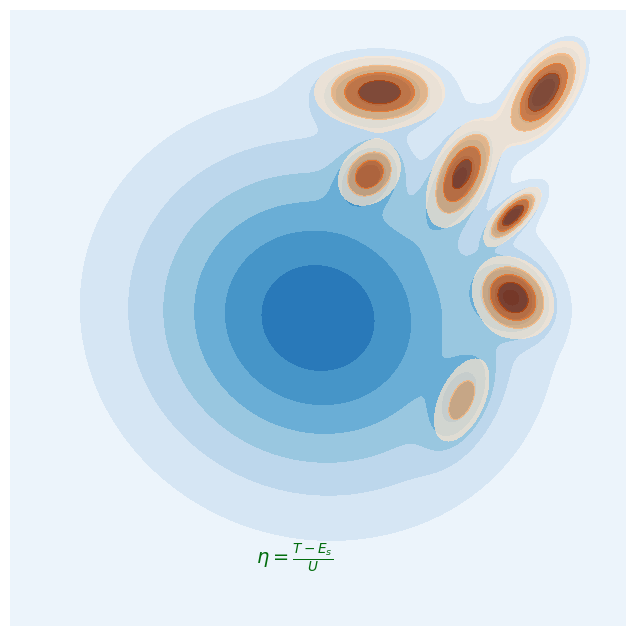

In [56]:
N = 300
xcen = N // 2
ycen = N // 2
x = np.linspace(0, N, N)
y = np.linspace(0, N, N)
X, Y = np.meshgrid(x, y)

halo = gaussian2d(
    X, Y,
    xcen, ycen,
    amp=1.0,
    sigma_x=60,
    sigma_y=55,
    theta=20
)

# subhalos
sub1 = gaussian2d(
    X, Y,
    180, 260,
    amp=0.92,
    sigma_x=18,
    sigma_y=10,
    theta=0
)

sub2 = gaussian2d(
    X, Y,
    245, 160,
    amp=0.98,
    sigma_x=12,
    sigma_y=10,
    theta=45
)

sub3 = gaussian2d(
    X, Y,
    245, 200,
    amp=0.98,
    sigma_x=4,
    sigma_y=10,
    theta=45
)

sub4 = gaussian2d(
    X, Y,
    175, 220,
    amp=0.78,
    sigma_x=8,
    sigma_y=10,
    theta=45
)

sub5 = gaussian2d(
    X, Y,
    220, 220,
    amp=0.88,
    sigma_x=8,
    sigma_y=16,
    theta=25
)

sub6 = gaussian2d(
    X, Y,
    220, 110,
    amp=0.48,
    sigma_x=8,
    sigma_y=16,
    theta=25
)

sub7 = gaussian2d(
    X, Y,
    260, 260,
    amp=0.98,
    sigma_x=8,
    sigma_y=16,
    theta=35
)

subs = sub1 + sub2 + sub3 + sub4 + sub5 + sub6 + sub7
halo = halo + subs

ax = plt.figure(figsize=(8, 8)).add_subplot(aspect="equal")

ax.contourf(X, Y, halo, levels=10, cmap="Blues")
ax.contourf(
    X, Y, subs,
    levels=np.linspace(subs.max()*0.2, subs.max(), 5),
    cmap="Oranges",
    alpha=0.7
)

ax.set_axis_off()

y_com, x_com = center_of_mass(halo)
# ax.scatter(x_com, y_com, color="white", s=200, edgecolors="k", label='COM')
# ax.scatter(xcen, ycen, color="red", s=200, edgecolors="k",
#            marker="X", label='Density Peak')

# ax.plot([xcen, x_com-1], [ycen, y_com-1], color="white",
#         lw=1, ls='--', markeredgecolor='k')

# rotated_marker = MarkerStyle(">").rotated(deg=36)

# ax.scatter([x_com - 1], [y_com - 1], color='white', s=20, marker=rotated_marker, edgecolors='k')

ax.annotate(
    text=r'$\eta = \frac{T - E_s}{U}$',
    xy=(120, 30),
    color="#026d0e",
    size=14,
)
# ax.legend()
plt.show()

In [42]:
morphs = pd.read_csv('results/zx/rin50.0kpc_rout1.0Mpc_205.csv', index_col=0)

In [45]:
morphs['C'].describe()

count    205.000000
mean       3.503913
std        1.209442
min        0.560443
25%        2.439647
50%        3.612161
75%        4.348090
max        6.597212
Name: C, dtype: float64

In [51]:
morphs.loc[morphs['C'] > 6.]

,xc_centroid,yc_centroid,ellipticity_asymmetry,ellipticity_centroid,elongation_asymmetry,elongation_centroid,orientation_centroid,xc_asymmetry,yc_asymmetry,orientation_asymmetry,...,sersic_xc,sersic_yc,sersic_ellip,sersic_theta,sersic_chi2_dof,flag,flag_sersic,flux_circ,flux_ellip,runtime (s)
ID,,,,,,,,,,,,,,,,,,,,,
25,1026.244440,1006.440867,0.287034,0.283924,1.402592,1.396499,1.421994,1023.803045,1023.505195,1.428348,...,1023.799937,1023.501825,0.016612,1.515193,3.975826e+04,1,0,9.416969e+12,8.984616e+12,6182.635338
79,1008.501700,1051.713173,0.271861,0.263044,1.373364,1.356933,-1.349151,1023.540368,1023.530878,-1.333191,...,1023.543274,1023.529206,0.045977,1.654197,7.235904e+04,1,0,8.235468e+12,9.206330e+12,209.528568
101,1025.036398,1052.263131,0.365454,0.359091,1.575929,1.560283,-1.480782,1023.456678,1023.514827,-1.485859,...,1028.312188,1036.496773,0.627072,1.676011,1.674782e+07,1,2,9.547641e+12,1.932458e+13,580.024393
194,1050.683257,1020.220875,0.224112,0.240982,1.288846,1.317492,-1.436310,1023.463088,1023.491259,-1.418596,...,1022.414543,1025.524139,0.533185,1.921233,1.464804e+07,1,0,7.072745e+12,1.048921e+13,494.372639


In [52]:
morphs.loc[morphs['C'] < 1.]

,xc_centroid,yc_centroid,ellipticity_asymmetry,ellipticity_centroid,elongation_asymmetry,elongation_centroid,orientation_centroid,xc_asymmetry,yc_asymmetry,orientation_asymmetry,...,sersic_xc,sersic_yc,sersic_ellip,sersic_theta,sersic_chi2_dof,flag,flag_sersic,flux_circ,flux_ellip,runtime (s)
ID,,,,,,,,,,,,,,,,,,,,,
154,1014.328846,1037.694672,0.149711,0.149711,1.176071,1.176071,-0.912658,1014.328846,1037.694672,-0.912658,...,1023.268652,1023.389636,0.404921,2.419266,1.793163e+07,2,0,4.869304e+12,4.816379e+12,270.421139
188,1061.680033,1004.431331,0.366626,0.366626,1.578845,1.578845,-1.064958,1061.680033,1004.431331,-1.064958,...,1053.744150,1014.176404,0.419687,2.210719,2.217454e+07,2,2,7.250316e+12,8.709403e+12,365.276919


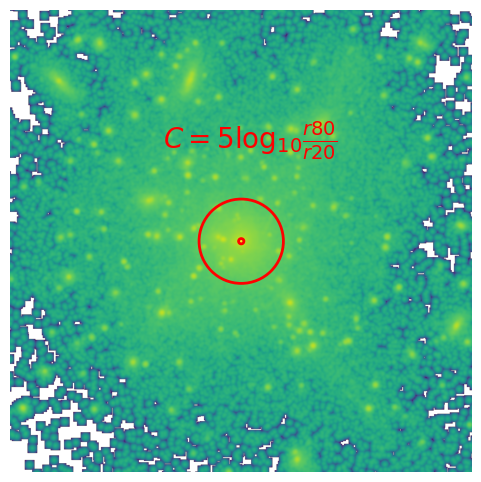

In [86]:
id = 79
data = fits.open(f'data/maps/xy/bcg_{id:04d}_125_0.fits')[0].data
cdata = imutils.crop(data, 500)

r20 = morphs.loc[id, 'r20']
# r50 = morphs.loc[id, 'rhalf_ellip']
r80 = morphs.loc[id, 'r80']

cen = len(data) // 2
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(cdata, origin='upper', norm=LogNorm())
cen = len(cdata) // 2
ax.add_patch(Circle((cen, cen), r20, edgecolor='red', facecolor='none', lw=2, label='r20'))
# ax.add_patch(Circle((cen, cen), r50, edgecolor='orange', facecolor='none', lw=2, label='r50'))
ax.add_patch(Circle((cen, cen), r80, edgecolor='red', facecolor='none', lw=2, label='r80'))
ax.annotate(
    text=r"$C = 5\text{log}_{10} \frac{{r80}}{{r20}}$",
    xy=(cen-170, cen-200),
    color="red",
    size=20,
)
ax.axis('off')
plt.show()

In [3]:
import utils.data as datutils
import astropy.units as u

In [103]:
id = 79
data = fits.open(f'data/maps/xy/bcg_{id:04d}_125_0.fits')[0].data
r_core = datutils.real2pix(30*u.kpc, data)
r_inner = datutils.real2pix(50*u.kpc, data)
r_outer = datutils.real2pix(1000*u.kpc, data)

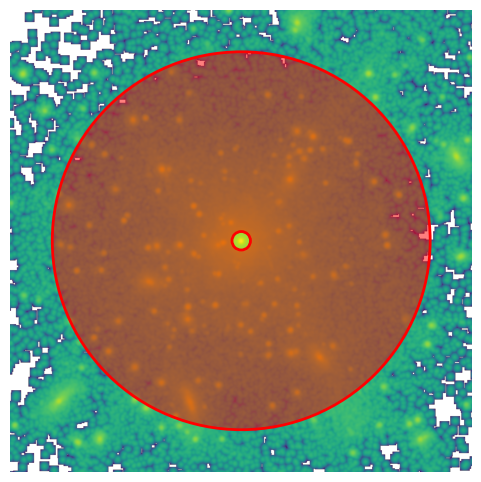

In [ ]:
id = 79
data = fits.open(f'data/maps/xy/bcg_{id:04d}_125_0.fits')[0].data
cdata = imutils.crop(data, 500)
rotated_cdata = np.rot90(cdata, k=2)
sub = cdata - rotated_cdata
r20 = morphs.loc[id, 'r20']
r50 = morphs.loc[id, 'r50']
r80 = morphs.loc[id, 'r80']

cen = len(data) // 2
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(cdata, origin='lower', norm=LogNorm())
cen = len(cdata) // 2

# ax.add_patch(Circle((cen, cen), r_outer, edgecolor='red',
#              facecolor='none', lw=2, label='r20'))
# ax.add_patch(Circle((cen, cen), r50, edgecolor='orange', facecolor='none', lw=2, label='r50'))
ax.add_patch(Circle((cen, cen), r_core, edgecolor='red',
             facecolor='none', lw=2, label='r80'))
# ann = Wedge((cen, cen), r_outer, 0, 360,
#             width=(r_outer - r_inner),
#             facecolor='red', alpha=0.5, edgecolor='none')
# ax.add_patch(ann)
# ax.annotate(
#     text=r"$C = 5\text{log}_{10} \frac{{r80}}{{r20}}$",
#     xy=(cen-170, cen-200),
#     color="red",
#     size=20,
# )
ax.axis('off')
plt.show()

In [7]:
import statmorph
import numpy as np
from astropy.io import fits

# Load your problem image
hdu = fits.open('data/maps/new_xy/bcg_0280_125_0.fits.gz')
image = hdu[0].data

# Check for obvious issues
print("Min/max flux:", np.nanmin(image), np.nanmax(image))
print("NaN count:", np.sum(np.isnan(image)))
print("Negative pixel fraction:", np.mean(image < 0))

Min/max flux: 0.0 4782158577.124952
NaN count: 0
Negative pixel fraction: 0.0


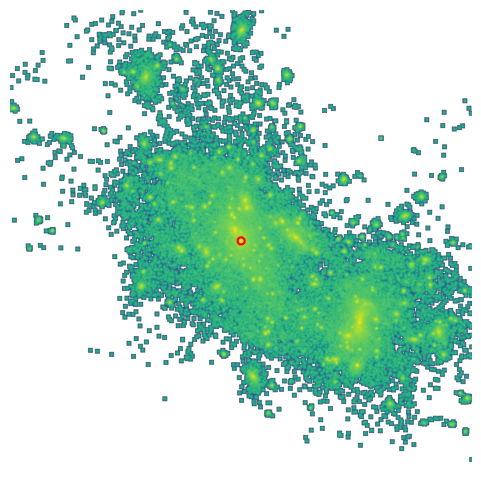

In [12]:
r = datutils.real2pix(40*u.kpc, image)
cen = len(image) // 2
segmap = imutils.circular_segmap(image, image_center=(cen, cen), radius=r)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image, origin='lower', norm=LogNorm())
ax.contour(segmap, colors='red', levels=[0.5])
ax.set_axis_off()
plt.show()

In [13]:
flux_in = image[segmap == 1].sum()
flux_out = image[segmap == 0].sum()
print(
    f"Flux fraction inside 30 kpc aperture: {flux_in/(flux_in+flux_out):.2%}")

Flux fraction inside 30 kpc aperture: 3.87%
